<a href="https://colab.research.google.com/github/DylanMCullifer/NetworkScienceProject/blob/main/Final_Project_NS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyzing Congressional Political Polarization 2018-2022

Dylan Cullifer


## Data Loading and Structuring

In [94]:
# Dylan Cullifer
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random, time
import sklearn
import scipy
import pandas as pd
import networkx.algorithms.community as co
from sentence_transformers import SentenceTransformer

# Read in all the data for the candidates
biographical_narratives = pd.read_csv("https://raw.githubusercontent.com/nurfnick/NetworkScience/refs/heads/main/Project/biographical_narratives.csv")
policy_platforms = pd.read_csv("https://raw.githubusercontent.com/nurfnick/NetworkScience/refs/heads/main/Project/policy_platforms.csv")
policy_platforms_aggregated = pd.read_csv("https://raw.githubusercontent.com/nurfnick/NetworkScience/refs/heads/main/Project/policy_platforms_aggregated.csv")

merge_cols = ["candidate_webname","state_postal","cd","year","cand_party"]

# drop all entries that lack key values needed
clean_bio = biographical_narratives.dropna(subset=merge_cols)
clean_policy = policy_platforms.dropna(subset=merge_cols)
clean_policy_agg = policy_platforms_aggregated.dropna(subset=merge_cols)

# removed weird starting index column that isn't needed
clean_bio = clean_bio.drop(clean_bio.columns[0], axis=1)
clean_policy = clean_policy.drop(clean_policy.columns[0], axis=1)

# these cols appear in both but are the same so I drop them for an easy merge
drop_duplicate_cols = ["primary_type","dem_prez_vote","inc","quality_cand","win_primary","primary_pct","win_general","general_pct","FECCandID","BIOGUIDE_id"]
bio_no_dups = clean_bio.drop(columns=drop_duplicate_cols)

all_data = clean_policy.merge(bio_no_dups, on=merge_cols, how="left").merge(clean_policy_agg, on=merge_cols, how="left")

# Condenses data to one candidate row per year with their multiple stances in that year put into a set
varying_cols = all_data.groupby(merge_cols).nunique().gt(1).any()
varying_columns = varying_cols[varying_cols].index.to_list()

# columns that don't change just have that value 
consistent_cols = [col for col in all_data.columns if col not in merge_cols and col not in varying_columns]
combined_dict = {col: "first" for col in consistent_cols}
combined_dict.update({col: lambda x: set(x) for col in varying_columns})

all_data = all_data.groupby(merge_cols, as_index=False).agg(combined_dict)

print("Total Candidate data shape:", all_data.shape)

# split data as needed by year and fix indexs since they transfer from the full set somehow
all_data_2018 = all_data[all_data["year"] == 2018]
all_data_2020 = all_data[all_data["year"] == 2020]
all_data_2022 = all_data[all_data["year"] == 2022]

all_data_2018 = all_data_2018.drop_duplicates(subset=["candidate_webname"])
all_data_2020 = all_data_2020.drop_duplicates(subset=["candidate_webname"])
all_data_2022 = all_data_2022.drop_duplicates(subset=["candidate_webname"])

all_data_2018 = all_data_2018.reset_index(drop=True)
all_data_2020 = all_data_2020.reset_index(drop=True)
all_data_2022 = all_data_2022.reset_index(drop=True)

print("2018 Candidate data shape:", all_data_2018.shape)
print("2020 Candidate data shape:", all_data_2020.shape)
print("2022 Candidate data shape:", all_data_2022.shape)
print()
print("Duplicate Check 2018:", all_data_2018["candidate_webname"].duplicated(keep=False).sum())
print("Duplicate Check 2020:", all_data_2020["candidate_webname"].duplicated(keep=False).sum())
print("Duplicate Check 2022:", all_data_2022["candidate_webname"].duplicated(keep=False).sum())

all_data_2020.head()

Total Candidate data shape: (4507, 23)
2018 Candidate data shape: (1499, 23)
2020 Candidate data shape: (1447, 23)
2022 Candidate data shape: (1558, 23)

Duplicate Check 2018: 0
Duplicate Check 2020: 0
Duplicate Check 2022: 0


,candidate_webname,state_postal,cd,year,cand_party,primary_type,dem_prez_vote,inc,quality_cand,win_primary,...,housegov_issue,FECCandID,BIOGUIDE_id,biography_text,housegov_bio,platform_text,issue_header,issue_text,policy_code,statement_id
0,Aaron Godfrey,OH,16,2020,Democrat,Open Primary,42.2,0,0,1,...,0,H8OH16090,None,One of three children in a working-class famil...,0.0,Healthcare: Despite the progress made under th...,"{Government Transparency, Education, Animal We...",{As a long-time volunteer at a local animal sh...,"{Defense, Education, Energy and Environment, H...","{15648, 15649, 15650, 15651, 15652, 15653, 156..."
1,Aaron Hermes,TX,22,2020,Republican,Open Primary,48.9,0,0,0,...,0,H0TX22328,None,MY BACKGROUND\r\r\n-Early Years \r\r\n\r\r\nI ...,0.0,'-Election Integrity: The technology and syste...,"{'-Protecting the Second Amendment, '-Election...","{The 2A is not about deer hunting, it's about ...","{Defense, Energy and Environment, Unknown, Imm...","{18187, 18188, 18189, 18190, 18191, 18192, 181..."
2,Aaron Scanlan,FL,21,2020,Republican,Closed Primary,58.2,0,0,0,...,0,H0FL21060,None,Aaron Scanlan is a principled conservative wit...,0.0,ECONOMIC DEVELOPMENT: While our economy now is...,"{FLORIDA'S WATERWAYS, ECONOMIC DEVELOPMENT, HE...",{Provide a safe and effective way of protectin...,"{Immigration, Economics and Commerce, Healthca...","{38040, 38037, 38038, 38039}"
3,Aaron Swisher,ID,2,2020,Democrat,Partially-Closed,36.6,0,0,1,...,0,H8ID02148,None,Aaron Swisher was born and raised in rural Wes...,0.0,MANAGING AND BALANCING THE FEDERAL BUDGET: Bec...,"{MANAGING AND BALANCING THE FEDERAL BUDGET, BO...",{Draining the Swamp needs to be more than just...,"{Education, Energy and Environment, Immigratio...","{41602, 41603, 41604, 41605, 41606, 41607, 416..."
4,Abby Finkenauer,IA,1,2020,Democrat,Open Primary,47.4,1,2,1,...,0,H8IA01094,None,Meet Abby\r\r\n\r\r\nAs the youngest woman eve...,0.0,Creating Jobs and a Strong Economy: As your re...,{Fighting for Good Schools and Affordable Coll...,{We must invest in our deteriorating and under...,"{Defense, Education, Energy and Environment, T...","{13631, 13632, 13633, 13634, 13635, 13636, 136..."


Here we load the csv data into frames for ease of handling. Each of the datasets where merged into a main set with all relevant data with duplicates across them dropped. Then all entries from a candidate from a given year are collapsed into one entry for that year where columns that don't change are one value and columns that do are a set of all their values.

In [95]:
#Dylan Cullifer
# grab all platform text from all candidates in a certain year
platform_text_2018 = all_data_2018["platform_text"].to_list()
platform_text_2020 = all_data_2020["platform_text"].to_list()
platform_text_2022 = all_data_2022["platform_text"].to_list()

transformer = SentenceTransformer("all-MiniLM-L6-v2")

# turn all stated platforms of each candidate into embeddings so we can compare them
platform_text_embeddings_2018 = transformer.encode(platform_text_2018, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True)
platform_text_embeddings_2020 = transformer.encode(platform_text_2020, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True)
platform_text_embeddings_2022 = transformer.encode(platform_text_2022, convert_to_numpy=True, normalize_embeddings=True, show_progress_bar=True)

print("Embedding shape:", platform_text_embeddings_2018[0].shape)

Batches: 100%|██████████| 49/49 [00:33<00:00,  1.47it/s]

Embedding shape: (384,)


Using a sentence transformer we can take text and turn each stated platform in a an embedding that represents the meaning. Using these embeddings we can compare all the candidates based their similarity of these embeddings. These Embeddings are 384 dimension long and are made from the all-MiniLM-L6-v2 which produces vectors that represent the text's semantic meaning, it can do this for both sentences and smaller paragraphs with good accuracy.

## Graph Creation

In [96]:
# Dylan Cullifer
# a node x node matrix that shows sim scores from one nodes embedding to another
sim_scores_2018 = sklearn.metrics.pairwise.cosine_similarity(platform_text_embeddings_2018)
sim_scores_2020 = sklearn.metrics.pairwise.cosine_similarity(platform_text_embeddings_2020)
sim_scores_2022 = sklearn.metrics.pairwise.cosine_similarity(platform_text_embeddings_2022)

print("Sim Matrix Shape:", sim_scores_2018.shape)

# cosine sim threshold for edge creation, was chosen to help maximize readability and edge signifigance 
# with this threshold 2 people need to share a good deal more than half of their platform to be linked 
# with this value we are able to capture most of the graph, roughly 75%, and filterout people that 
# have little meaningful overlap
sim_score_threshold = 0.67

G_2018 = nx.Graph()
G_2020 = nx.Graph()
G_2022 = nx.Graph()

# build graphs based on data from each year
def build_graph(sim, data, graph):
    for index, row in data.iterrows():
        # add attributes for assoritivity studies in the future
        graph.add_node(index,
         candidate_webname=row["candidate_webname"], cand_party=row["cand_party"], state_postal=row["state_postal"],
         cd=row["cd"], inc=row["inc"], primary_type=row["primary_type"])

    # add edges between nodes if their cos sim score of there platform embeddings meet a threshold
    for x in range(0, sim.shape[0]):
        sim_row = sim[x]
        sim_row[x] = 0
        all_rows = sim_row.argsort()
        for y in all_rows:
            edge_weight = sim[x,y]
            if edge_weight >= sim_score_threshold:
                graph.add_edge(x, y, weight=edge_weight)

    return graph

G_2018 = build_graph(sim_scores_2018, all_data_2018, G_2018)
G_2020 = build_graph(sim_scores_2020, all_data_2020, G_2020)
G_2022 = build_graph(sim_scores_2022, all_data_2022, G_2022)

print("Num Nodes 2018:", len(G_2018.nodes))
print("Num Edges 2018:", len(G_2018.edges))
print()
print("Num Nodes 2020:", len(G_2020.nodes))
print("Num Edges 2020:", len(G_2020.edges))
print()
print("Num Nodes 2022:", len(G_2022.nodes))
print("Num Edges 2022:", len(G_2022.edges))
print()
print("2018 Self Loop Check:", len(list(nx.selfloop_edges(G_2018))))
print("2020 Self Loop Check:", len(list(nx.selfloop_edges(G_2020))))
print("2022 Self Loop Check:", len(list(nx.selfloop_edges(G_2022))))


Sim Matrix Shape: (1499, 1499)
Num Nodes 2018: 1499
Num Edges 2018: 7426

Num Nodes 2020: 1447
Num Edges 2020: 4966

Num Nodes 2022: 1558
Num Edges 2022: 3373

2018 Self Loop Check: 0
2020 Self Loop Check: 0
2022 Self Loop Check: 0


Similarity matrices are made based on the embeddings comparing each vector to all others in the stack and giving a similarity value between 2 candidates stated platforms. Then I take each node and add helpful attributes that better identify the candidate from the row in the data frame. Edges are added between a given node and all other nodes that meet the assigned similarity threshold being 67%. This threshold was chosen because it struck a balance on amount of edges and nodes captured in LCC. This threshold also make sense because we should only care if the candidates are actually similar enough to be significant preventing useless edges.

In [128]:
# Dylan Cullifer
# reusable fucntion to make the graphs visual
def create_graph(graph, title, data):
    # party colors
    colors = {"Republican": "indianred", "Democrat": "cornflowerblue"}
    # lines colors, purple represents cross party lines and is a mix of red and blue / grey to show expected within faction connections
    line_color = {"Cross_party": "darkmagenta", "Inter_party": "gray"}

    # loop through the nodes and apply their party affiliation
    colors_nodes = []
    for entry in graph.nodes():
        cand_party = graph.nodes[entry].get("cand_party")
        if(cand_party != None):
            colors_nodes.append(colors[cand_party])
        else:
            colors_nodes.append("gray")

    all_edges = graph.edges(data=True)

    # holders for edges widths and colors
    edge_sizes = []
    color_edges = []
    max_dem_sim = 0
    max_rep_sim = 0
    # Holders for most alike candidates based on their platform text on a graph
    dem_node = (None, None, None)
    rep_node = (None, None, None)

    # count cross edge links per node
    node_cross_edge_counter = dict.fromkeys(graph.nodes(), 0)

    # loop through edges and apply colors and weights 
    for node1, node2, sim in all_edges:
        edge_sim_value = sim.get("weight", 0)
        # add width based on the similarity
        edge_size = max(0.4, (edge_sim_value - sim_score_threshold) * 10)
        edge_sizes.append(edge_size)

        # add colors and track most similiar
        if(graph.nodes[node1].get("cand_party") == graph.nodes[node2].get("cand_party")):
            color_edges.append(line_color["Inter_party"])
            if(graph.nodes[node1].get("cand_party") == "Democrat" and edge_sim_value > max_dem_sim):
                max_dem_sim = edge_sim_value
                dem_node = (node1, node2, edge_sim_value)
            elif(graph.nodes[node1].get("cand_party") == "Republican" and edge_sim_value > max_rep_sim):
                max_rep_sim = edge_sim_value
                rep_node = (node1, node2, edge_sim_value)
        else:
            color_edges.append(line_color["Cross_party"])
            node_cross_edge_counter[node1] += 1
            node_cross_edge_counter[node2] += 1

    # grab degrees and separte them from nodes 
    node_degrees = list(graph.degree(weight="weight"))
    just_degrees = [degree for node, degree in node_degrees]

    max_degree_found = max(just_degrees)
    min_degree_found = min(just_degrees)

    highest_degree_candidate = [candidate for candidate, degree in node_degrees if degree == max_degree_found]

    # still want nodes with no connections to be visable so min needs to be set
    min_node_size = 15
    max_node_size = 150
    node_size = []
    for node, degree in node_degrees:
        # get the norm value of the degree and map it to a min of 15 or max of 150 size and anything in between
        standardize = degree - min(just_degrees)
        standardize = standardize / (max(just_degrees) - min(just_degrees))
        new_size = min_node_size + (standardize * (max_node_size - min_node_size))
        node_size.append(new_size)

    # general graph metrics that may be useful
    top_sims = []
    top_sims.append(dem_node)
    top_sims.append(rep_node)

    print(title + ":")
    print("Number of Nodes:", len(graph.nodes()))
    print("Number of Edges:", len(graph.edges()))
    print("Highest Degree:", max_degree_found)
    print("Lowest Degree:", min_degree_found)
    print("Highest Degree Candidate:", 
          graph.nodes[highest_degree_candidate[0]]["candidate_webname"], " / ",
          graph.nodes[highest_degree_candidate[0]]["cand_party"], " / ",
          graph.nodes[highest_degree_candidate[0]]["state_postal"])
    
    print("Total Cross Party Connections:", color_edges.count(line_color["Cross_party"]))
    percent_cross_party_edges = (color_edges.count(line_color["Cross_party"]) / len(color_edges))
    print("Cross Party percent of total edges:", percent_cross_party_edges)

    # legend that shows what colors mean what
    dem_node_led = plt.matplotlib.patches.Patch(label="Democrat", color=colors["Democrat"])
    rep_node_led = plt.matplotlib.patches.Patch(label="Republican", color=colors["Republican"])
    within_party_line = plt.matplotlib.lines.Line2D(xdata=[], ydata=[], label="Edge in the same party", color=line_color["Inter_party"])
    cross_party_line = plt.matplotlib.lines.Line2D(xdata=[], ydata=[], label="Edge to other party", color=line_color["Cross_party"])

    plt.close("all")
    # size to fit on a power point slide perfectly, looked this value up
    # snipping tool to color match slides so it looks nicer
    plt.figure(figsize=(13.33, 7.5), facecolor="#F3F0E9")
    position = nx.spring_layout(graph, seed=1, k=5, iterations=100, scale=10, weight="weight")
    # position = nx.kamada_kawai_layout(graph, weight="weight")
    nx.draw_networkx_nodes(graph, pos=position, node_size=node_size, node_color=colors_nodes, edgecolors="black", linewidths=.3)
    nx.draw_networkx_edges(graph, pos=position, alpha=.8, width=edge_sizes, edge_color=color_edges)
    plt.legend(handles=[dem_node_led, rep_node_led, within_party_line, cross_party_line], loc="upper left")
    plt.title(title, fontsize=25, fontweight="bold")

    # makes graph better to read by removing excess white space
    plt.tight_layout()
    plt.margins(0)
    plt.axis("off")
    # helps with clearity on the slides, googled suggested these values
    plt.savefig(title + ".png", dpi=400, bbox_inches="tight", pad_inches=0)
    plt.show()

    return top_sims, percent_cross_party_edges, node_cross_edge_counter
    
# fucntion to just extract names and platform text for comparsion
def get_candidate_platform_text(most_sim, graph, dataFrame):
    cand_names = []
    most_sim_platform_text = []
    cand_names.append(graph.nodes[most_sim[0][0]].get("candidate_webname"))
    cand_names.append(graph.nodes[most_sim[0][1]].get("candidate_webname"))

    cand_names.append(graph.nodes[most_sim[1][0]].get("candidate_webname"))
    cand_names.append(graph.nodes[most_sim[1][1]].get("candidate_webname"))
    for entry in cand_names:
        most_sim_platform_text.append(dataFrame.loc[dataFrame["candidate_webname"] == entry, "platform_text"].iloc[0])
    
    return most_sim_platform_text, cand_names


The above create graph function creates the graph visuals for each of the years datasets showing the change over time in republican and democrat connections. Node sizes vary by degree importance and edges vary in width by strength. Democrats are show in blue and Republicans in red, within party connections are shown in gray and cross party connections are shown in purple. Even with a higher threshold the graph was very dense so I had to tune much of the node spacing and scale to strike a good balance for extra readability. A series of metrics are found as well like the max and min degrees and the candidate that has the highest degree for that network. The cross party lines are also tracked and their total percentage of the graph edges.

2018 Similarity Graph:
Number of Nodes: 1499
Number of Edges: 7426
Highest Degree: 103.4276
Lowest Degree: 0
Highest Degree Candidate: Matthew Brolley  /  Democrat  /  IL
Total Cross Party Connections: 1615
Cross Party percent of total edges: 0.21747912739025047


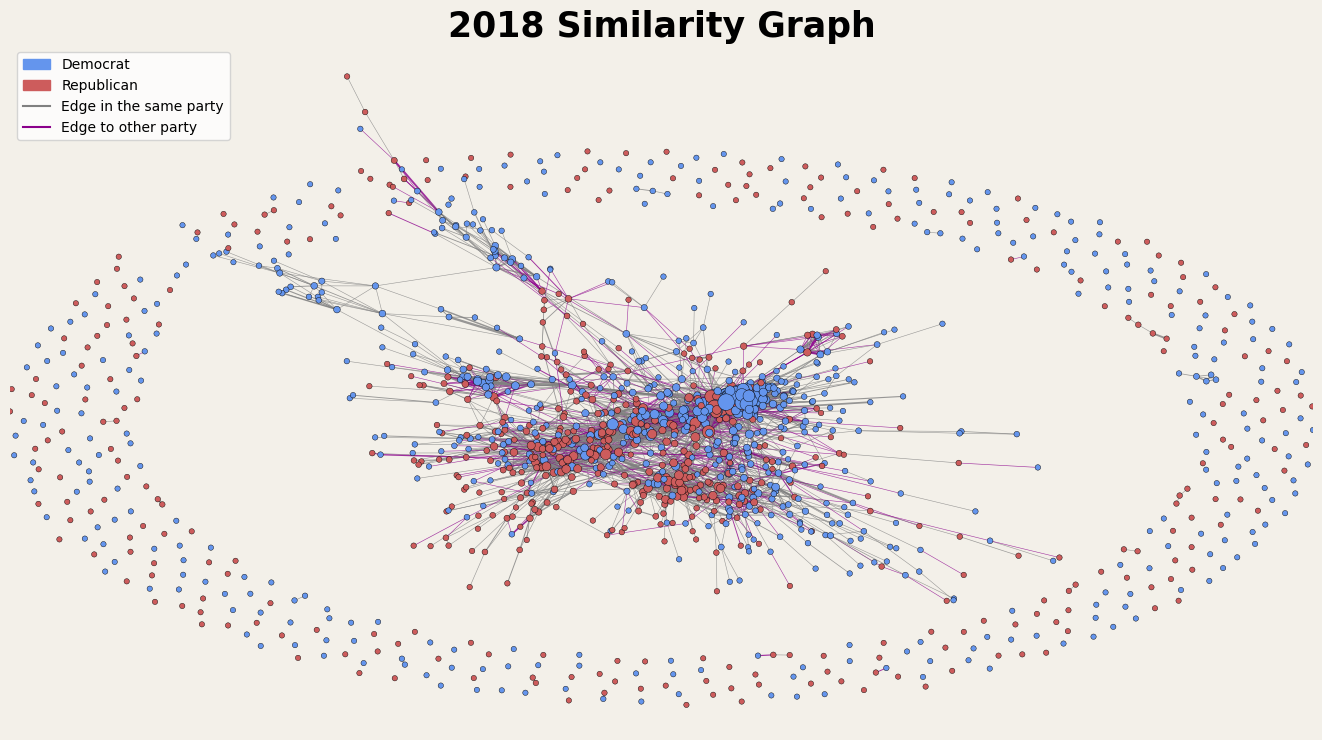

Most Similar Candidates:
Dems: John Russell / Michael Milisits
Reps: Bob Corlew / Hank Hamblin
Strong Similarity Text Example:
Text 1: Tennessee Conservative Values: As a Christian conservative, veteran, and judge, I am 100% pro-life and a firm supporter of our 2nd Amendment rights. We must restore the rule of law, fight for limited government, and ensure our conservative Tennessee values are represented in Washington, D.C. I will work with and support President Trump in achieving our shared agenda and standing up for our values. Immigration: We are a nation of laws, and those laws must be upheld and respected first and foremost. That means no amnesty for illegal aliens, build the wall to protect our citizens and fix our broken borders, and put an end to chain migration. Military and Veterans: As a veteran, I understand the challenges our service men, service women, and their families face. We must fix the broken VA system and hold bureaucrats accountable to ensure our veterans receive

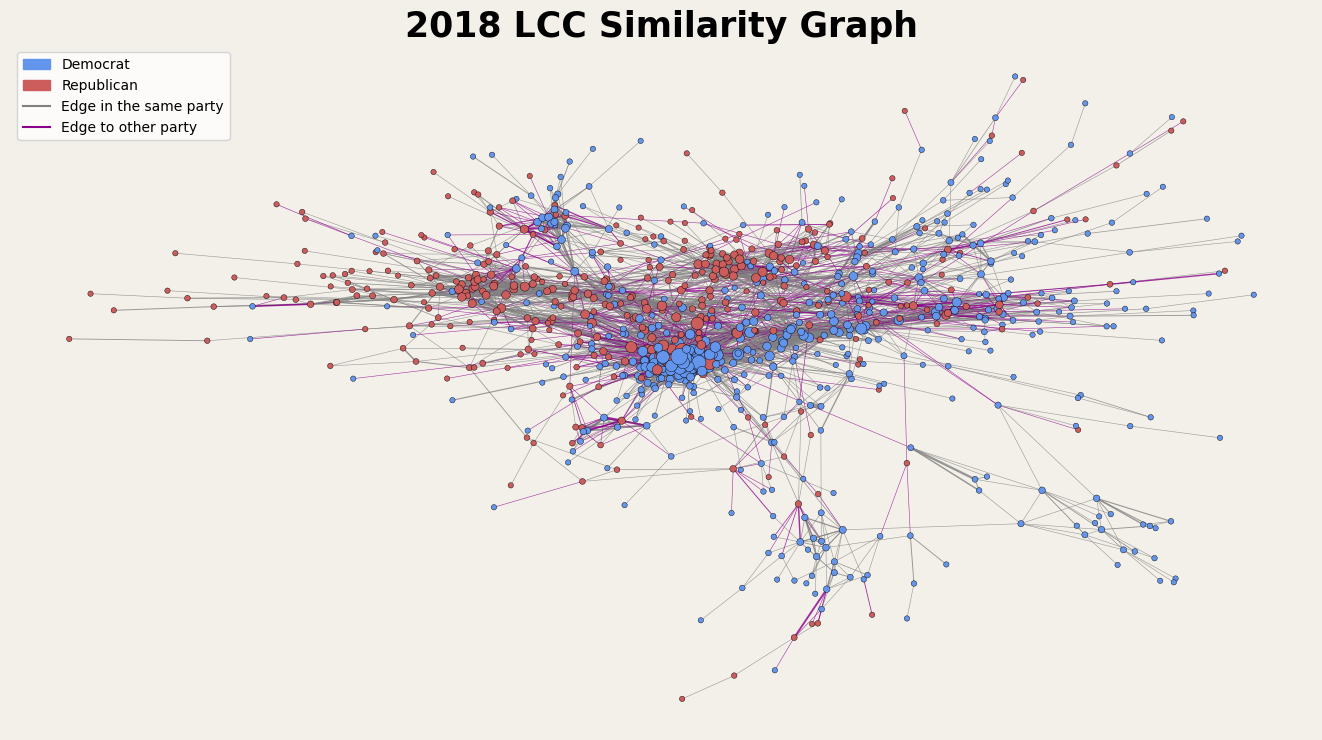


Most Similar Candidates:
Dems: John Russell / Michael Milisits
Reps: Bob Corlew / Hank Hamblin




In [129]:
# Dylan Cullifer
# full graph 2018
most_sim_2018, percent_cross_party_2018, cross_party_counts_2018 = create_graph(G_2018, "2018 Similarity Graph", all_data_2018)
most_sim_text_2018, most_sim_names_2018 = get_candidate_platform_text(most_sim_2018, G_2018, all_data_2018)

print("Most Similar Candidates:")
print("Dems:", most_sim_names_2018[0], "/",  most_sim_names_2018[1])
print("Reps:", most_sim_names_2018[2], "/",  most_sim_names_2018[3])

print("Strong Similarity Text Example:")
print("Text 1:", most_sim_text_2018[2])
print("Text 2:", most_sim_text_2018[3])
print()

# LCC graph 2018
components_2018 = nx.connected_components(G_2018)
G_2018_LCC = G_2018.subgraph(max(components_2018, key=len)).copy()

most_sim_2018_LCC, percent_cross_party_2018_LCC, cross_party_counts_2018_LCC = create_graph(G_2018_LCC, "2018 LCC Similarity Graph", all_data_2018)
most_sim_text_2018_LCC, most_sim_names_2018_LCC = get_candidate_platform_text(most_sim_2018_LCC, G_2018_LCC, all_data_2018)

print()
print("Most Similar Candidates:")
print("Dems:", most_sim_names_2018_LCC[0], "/",  most_sim_names_2018_LCC[1])
print("Reps:", most_sim_names_2018_LCC[2], "/",  most_sim_names_2018_LCC[3])
print("\n")

Both the full dataset and LCC are plotted for comparison since a smaller portion of the candidates are independent enough to miss being included in the LCC.

2020 Similarity Graph:
Number of Nodes: 1447
Number of Edges: 4966
Highest Degree: 74.24274
Lowest Degree: 0
Highest Degree Candidate: Tammy Young  /  Democrat  /  TX
Total Cross Party Connections: 1260
Cross Party percent of total edges: 0.25372533225936367


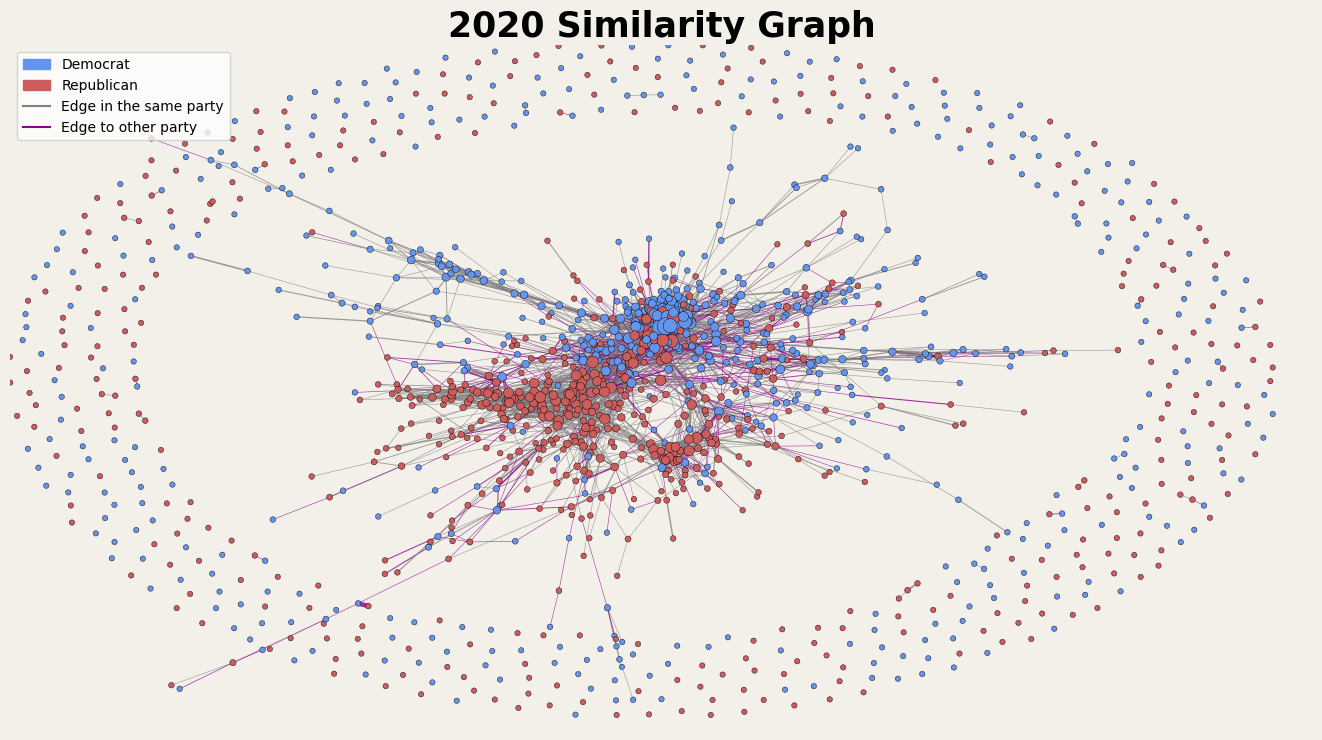

Most Similar Candidates:
Dems: Donna Deegan / Elissa Slotkin
Reps: Bob Latta / Glenn Grothman

2020 LCC Similarity Graph:
Number of Nodes: 863
Number of Edges: 4938
Highest Degree: 74.24274
Lowest Degree: 0.67003787
Highest Degree Candidate: Tammy Young  /  Democrat  /  TX
Total Cross Party Connections: 1249
Cross Party percent of total edges: 0.25293641150263263


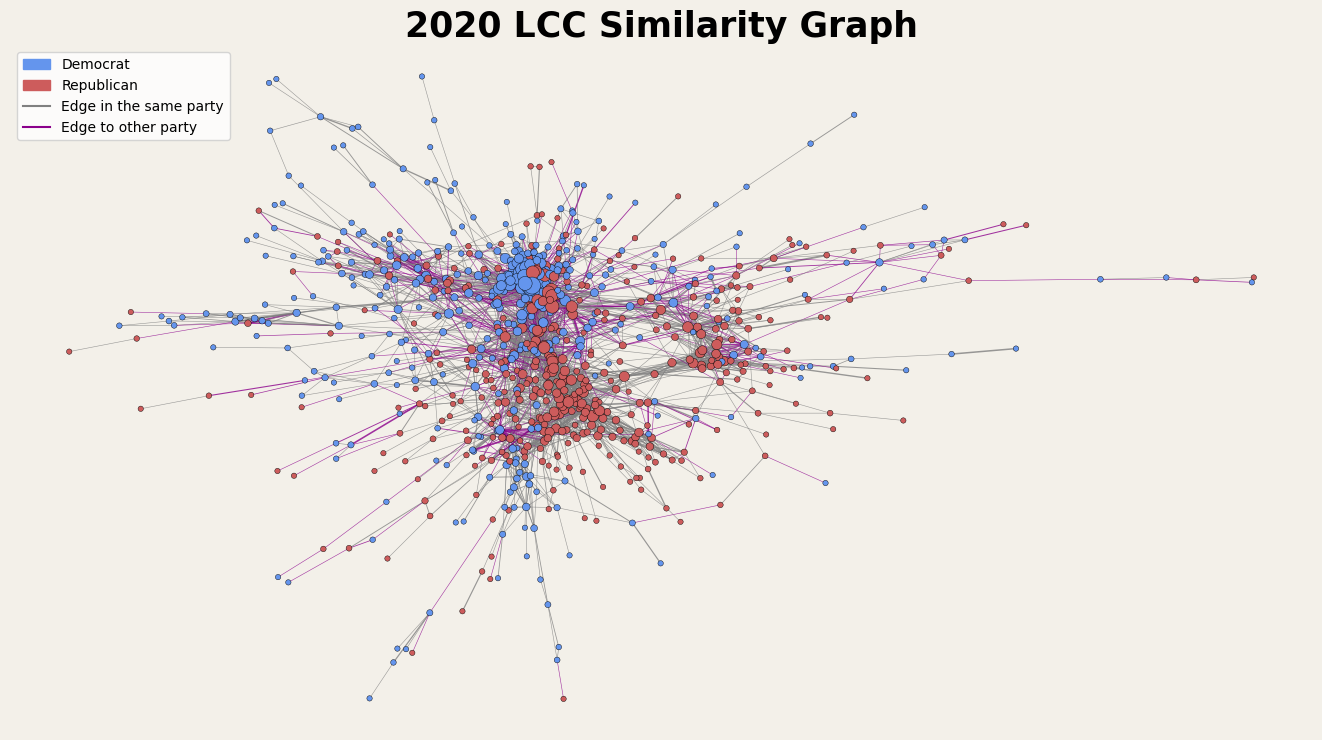

Most Similar Candidates:
Dems: Donna Deegan / Elissa Slotkin
Reps: Bob Latta / Glenn Grothman




In [130]:
# Dylan Cullifer
# full graph 2020
most_sim_2020, percent_cross_party_2020, cross_party_counts_2020 = create_graph(G_2020, "2020 Similarity Graph", all_data_2020)
most_sim_text_2020, most_sim_names_2020 = get_candidate_platform_text(most_sim_2020, G_2020, all_data_2020)

print("Most Similar Candidates:")
print("Dems:", most_sim_names_2020[0], "/",  most_sim_names_2020[1])
print("Reps:", most_sim_names_2020[2], "/",  most_sim_names_2020[3])
print()

# LCC graph 2020
components_2020 = nx.connected_components(G_2020)
G_2020_LCC = G_2020.subgraph(max(components_2020, key=len)).copy()

most_sim_2020_LCC, percent_cross_party_2020_LCC, cross_party_counts_2020_LCC = create_graph(G_2020_LCC, "2020 LCC Similarity Graph", all_data_2020)
most_sim_text_2020_LCC, most_sim_names_2020_LCC = get_candidate_platform_text(most_sim_2020_LCC, G_2020_LCC, all_data_2020)

print("Most Similar Candidates:")
print("Dems:", most_sim_names_2020_LCC[0], "/",  most_sim_names_2020_LCC[1])
print("Reps:", most_sim_names_2020_LCC[2], "/",  most_sim_names_2020_LCC[3])
print("\n")

2022 Similarity Graph:
Number of Nodes: 1558
Number of Edges: 3373
Highest Degree: 43.59523
Lowest Degree: 0
Highest Degree Candidate: J. Michael Davisson  /  Republican  /  IN
Total Cross Party Connections: 380
Cross Party percent of total edges: 0.1126593536910762


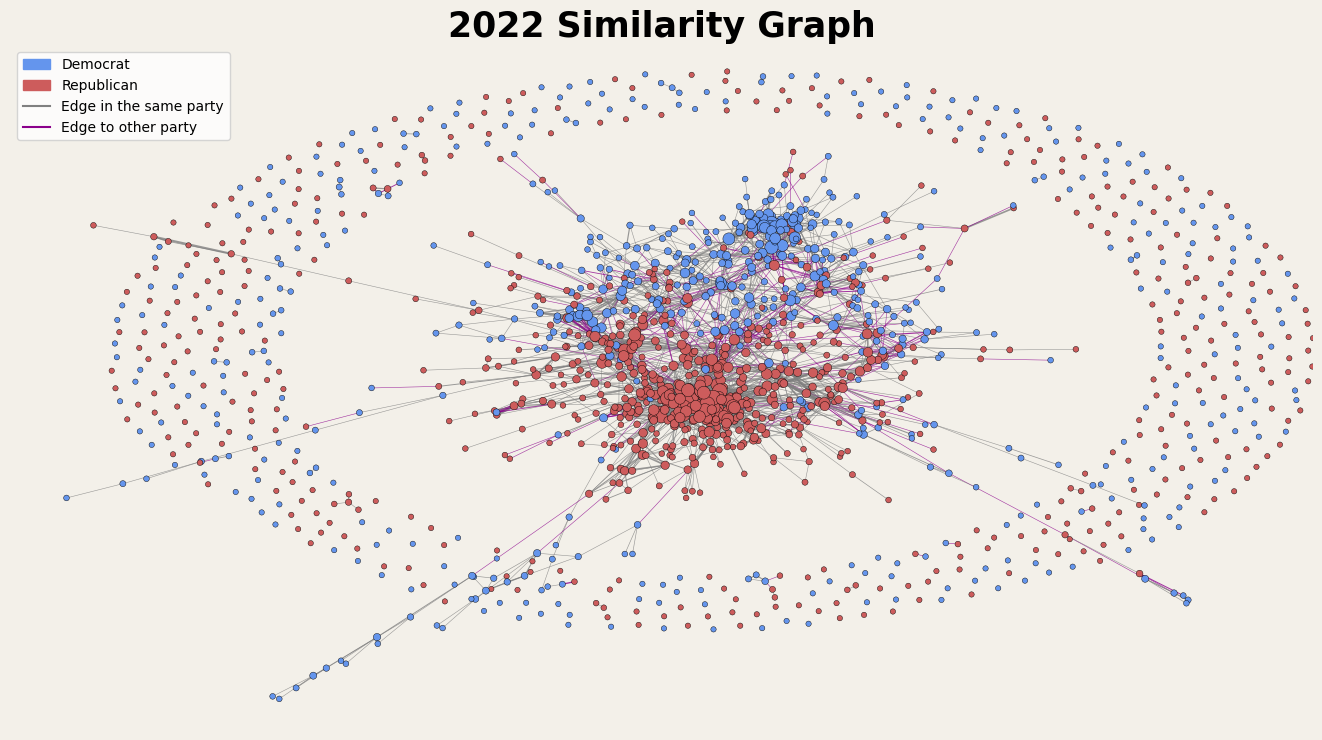

Most Similar Candidates:
Dems: Jamie Cheney / John S Selker
Reps: J. Michael Davisson / Wesley Hunt

2022 LCC Similarity Graph:
Number of Nodes: 924
Number of Edges: 3331
Highest Degree: 43.59523
Lowest Degree: 0.67000407
Highest Degree Candidate: J. Michael Davisson  /  Republican  /  IN
Total Cross Party Connections: 369
Cross Party percent of total edges: 0.1107775442809967


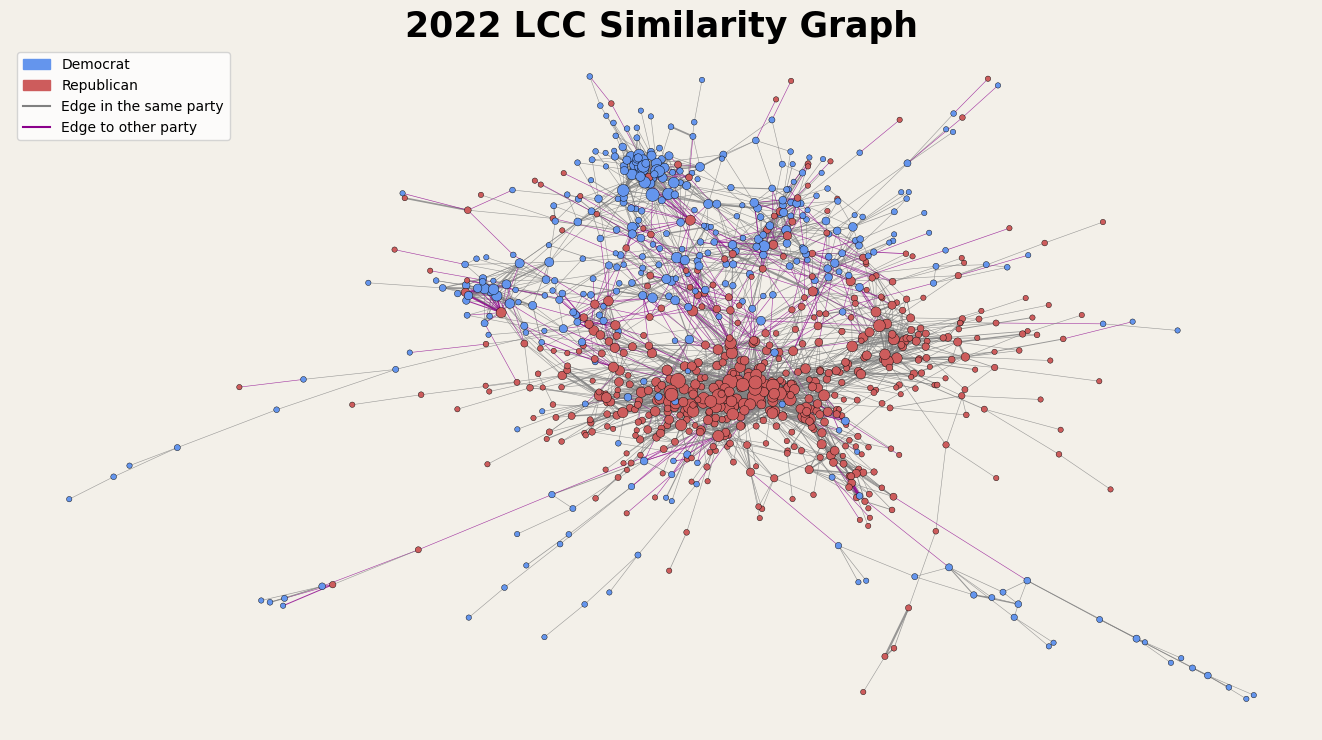

Most Similar Candidates:
Dems: Jamie Cheney / John S Selker
Reps: J. Michael Davisson / Wesley Hunt




In [131]:
# Dylan Cullifer
# full graph 2022
most_sim_2022, percent_cross_party_2022, cross_party_counts_2022 = create_graph(G_2022, "2022 Similarity Graph", all_data_2022)
most_sim_text_2022, most_sim_names_2022 = get_candidate_platform_text(most_sim_2022, G_2022, all_data_2022)

print("Most Similar Candidates:")
print("Dems:", most_sim_names_2022[0], "/",  most_sim_names_2022[1])
print("Reps:", most_sim_names_2022[2], "/",  most_sim_names_2022[3])
print()

# LCC graph 2022
components_2022 = nx.connected_components(G_2022)
G_2022_LCC = G_2022.subgraph(max(components_2022, key=len)).copy()

most_sim_2022_LCC, percent_cross_party_2022_LCC, cross_party_counts_2022_LCC = create_graph(G_2022_LCC, "2022 LCC Similarity Graph", all_data_2022)
most_sim_text_2022_LCC, most_sim_names_2022_LCC = get_candidate_platform_text(most_sim_2022_LCC, G_2022_LCC, all_data_2022)

print("Most Similar Candidates:")
print("Dems:", most_sim_names_2022_LCC[0], "/",  most_sim_names_2022_LCC[1])
print("Reps:", most_sim_names_2022_LCC[2], "/",  most_sim_names_2022_LCC[3])
print("\n")

## Party Distribution and Similarity Shifts

In [132]:
# Dylan Cullifer
# show percentage what percentage LCC is to full dataset
print("2018 LCC Size Percantage:")
print("Nodes:", (len(G_2018_LCC.nodes()) / len(G_2018.nodes()))* 100)
print("Edges:", (len(G_2018_LCC.edges()) / len(G_2018.edges()))* 100)
print()

print("2020 LCC Size Percantage:")
print("Nodes:", (len(G_2020_LCC.nodes()) / len(G_2020.nodes()))* 100)
print("Edges:", (len(G_2020_LCC.edges()) / len(G_2020.edges()))* 100)
print()

print("2022 LCC Size Percantage:")
print("Nodes:", (len(G_2022_LCC.nodes()) / len(G_2022.nodes()))* 100)
print("Edges:", (len(G_2022_LCC.edges()) / len(G_2022.edges()))* 100)
print()

2018 LCC Size Percantage:
Nodes: 64.97665110073382
Edges: 99.56908160517102

2020 LCC Size Percantage:
Nodes: 59.64063579820318
Edges: 99.43616592831252

2022 LCC Size Percantage:
Nodes: 59.306803594351734
Edges: 98.75481766973022



The metrics here are to see the percentage of candidates included in the LCC each year. The majority are captured in all years with the given threshold. The amount of edges is not expected to change since this is a cosine sim graph and thus the LCC will have virtually every edge since they are the main factions in each party.

2018 Candidates:
Number of Dems: 868
Number of Reps: 631
[[0.94317794]]

2020 Candidates:
Number of Dems: 726
Number of Reps: 721
[[0.9372721]]

2022 Candidates:
Number of Dems: 667
Number of Reps: 891
[[0.92434573]]

2018 LCC Candidates:
Number of Dems: 586
Number of Reps: 388
[[0.93099755]]

2020 LCC Candidates:
Number of Dems: 431
Number of Reps: 432
[[0.9157182]]

2022 LCC Candidates:
Number of Dems: 372
Number of Reps: 552
[[0.9028034]]



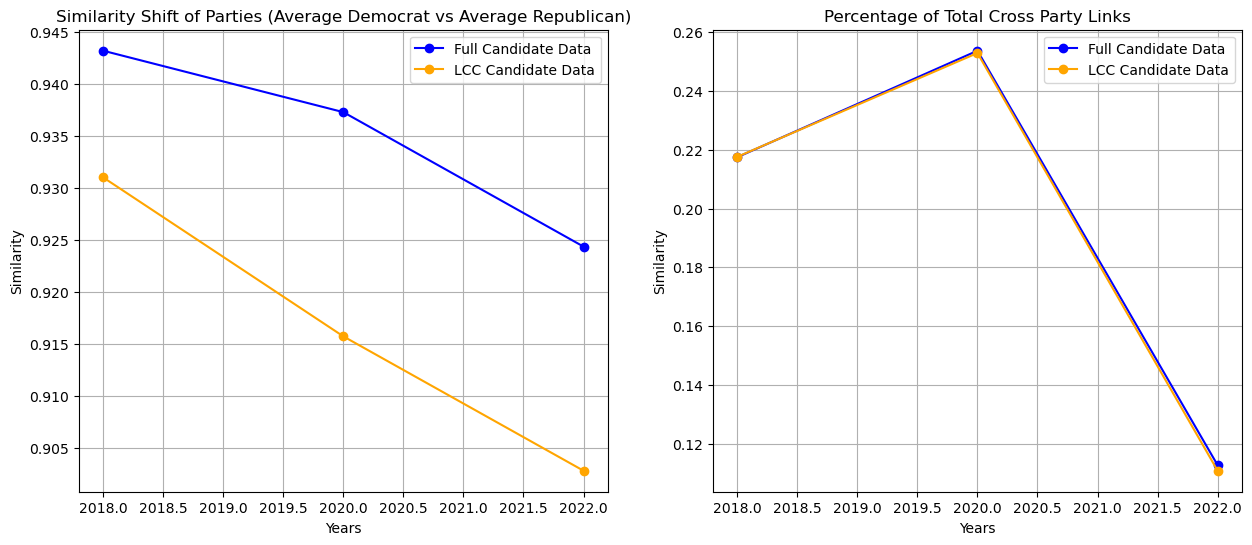

In [133]:
# Dylan Cullifer
# Average Democrat platform embedding vs average Republican platform embeddding difference
def show_full_party_shift(graph, title, embeddings):
    # gather embedding for each party
    dem_nodes = [node for node, nodeData in graph.nodes(data=True) if nodeData.get("cand_party") == "Democrat"]
    rep_nodes = [node for node, nodeData in graph.nodes(data=True) if nodeData.get("cand_party") == "Republican"]

    print(title)
    print("Number of Dems:", len(dem_nodes))
    print("Number of Reps:", len(rep_nodes))

    dem_platform_embeddings = embeddings[dem_nodes]
    rep_platform_embeddings = embeddings[rep_nodes]

    # get the average of the embeddings from each party
    dem_mean = dem_platform_embeddings.mean(axis=0, keepdims=True)
    rep_mean = rep_platform_embeddings.mean(axis=0, keepdims=True)

    total_party_sim = sklearn.metrics.pairwise.cosine_similarity(dem_mean, rep_mean)
    print(total_party_sim)
    print()

    return total_party_sim[0][0], [dem_nodes, rep_nodes]

years = [2018, 2020, 2022]

# returns the sim of the average party embeddings for a given year and the democrat/republican nodes
average_sim_2018_full, candidate_nodes_2018_full = show_full_party_shift(G_2018, "2018 Candidates:", platform_text_embeddings_2018)
average_sim_2020_full, candidate_nodes_2020_full = show_full_party_shift(G_2020, "2020 Candidates:", platform_text_embeddings_2020)
average_sim_2022_full, candidate_nodes_2022_full = show_full_party_shift(G_2022, "2022 Candidates:", platform_text_embeddings_2022)

average_sim_2018_LCC, candidate_nodes_2018_LCC = show_full_party_shift(G_2018_LCC, "2018 LCC Candidates:", platform_text_embeddings_2018)
average_sim_2020_LCC, candidate_nodes_2020_LCC = show_full_party_shift(G_2020_LCC, "2020 LCC Candidates:", platform_text_embeddings_2020)
average_sim_2022_LCC, candidate_nodes_2022_LCC = show_full_party_shift(G_2022_LCC, "2022 LCC Candidates:", platform_text_embeddings_2022)

total_sim_full = [average_sim_2018_full, average_sim_2020_full, average_sim_2022_full]
total_sim_LCC = [average_sim_2018_LCC, average_sim_2020_LCC, average_sim_2022_LCC]

cross_party_full = [percent_cross_party_2018, percent_cross_party_2020, percent_cross_party_2022]
cross_party_LCC = [percent_cross_party_2018_LCC, percent_cross_party_2020_LCC, percent_cross_party_2022_LCC]

plt.close("all")
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.title("Similarity Shift of Parties (Average Democrat vs Average Republican)")
plt.plot(years, total_sim_full, color="blue", label="Full Candidate Data", marker="o")
plt.plot(years, total_sim_LCC, color="orange", label="LCC Candidate Data", marker="o")
plt.legend()
plt.grid(True)
plt.xlabel("Years")
plt.ylabel("Similarity")

plt.subplot(1, 2, 2)
plt.title("Percentage of Total Cross Party Links")
plt.plot(years, cross_party_full, color="blue", label="Full Candidate Data", marker="o")
plt.plot(years, cross_party_LCC, color="orange", label="LCC Candidate Data", marker="o")
plt.legend()
plt.grid(True)
plt.xlabel("Years")
plt.ylabel("Similarity")
plt.show()

The above graph shows the full party similarity trends, this is done by taking all the embeddings for a given party and taking the average then doing the cosine similarity with the opposing party. This shows that as a whole the candidates running for each party are moving farther from each other even when the more moderate/independent candidates on each side are included. The graph on the right show the percent of total edges that reach across party lines and we can see a very sharp decline over the three election cycles. Cross party links drop by nearly half from 2018 to 2022 but see a slight uptake in 2020 likely due to the covid pandemic which may push candidates into similar positions.

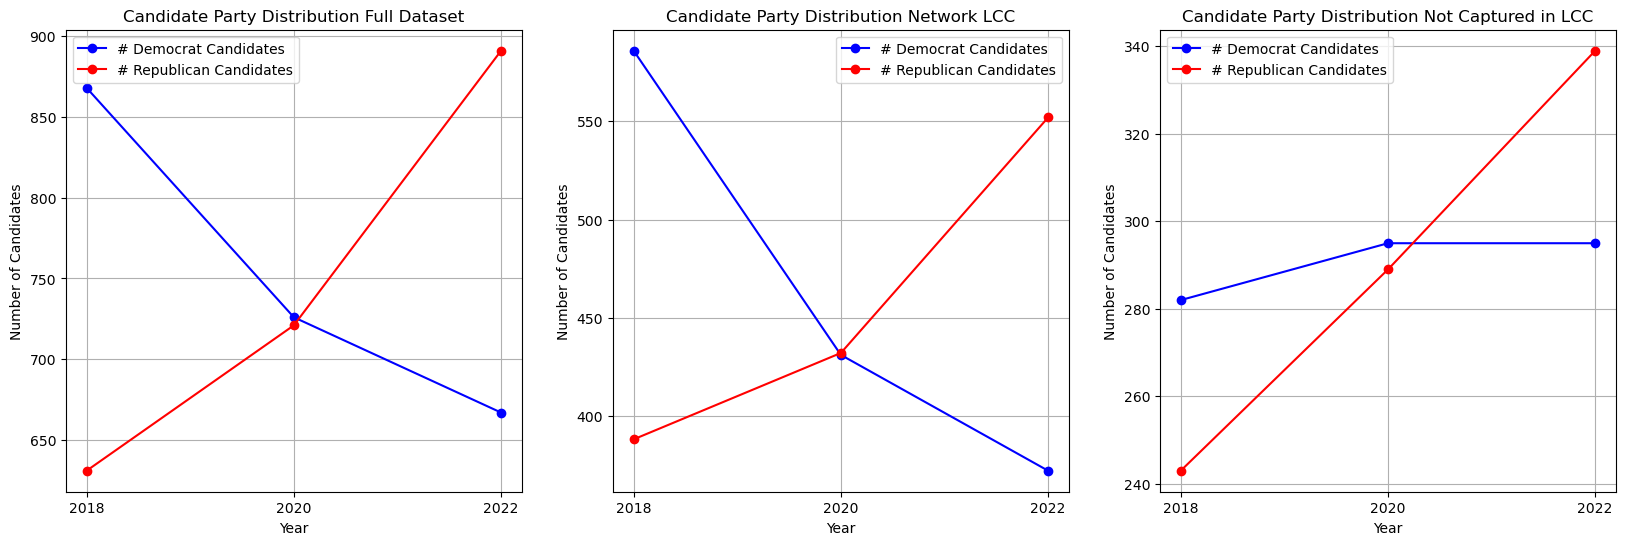

In [134]:
# Dylan Cullifer
# Takes the democrat and republican nodes and find the difference or the nodes not captured by the LCC to measure the distribution of candidates with more independent platforms
# index 0 here are democrat nodes and index 1 are republican nodes
add_candidates_not_in_lcc_2018 = [set(candidate_nodes_2018_full[0]) - set(candidate_nodes_2018_LCC[0]), set(candidate_nodes_2018_full[1]) - set(candidate_nodes_2018_LCC[1])]
add_candidates_not_in_lcc_2020 = [set(candidate_nodes_2020_full[0]) - set(candidate_nodes_2020_LCC[0]), set(candidate_nodes_2020_full[1]) - set(candidate_nodes_2020_LCC[1])]
add_candidates_not_in_lcc_2022 = [set(candidate_nodes_2022_full[0]) - set(candidate_nodes_2022_LCC[0]), set(candidate_nodes_2022_full[1]) - set(candidate_nodes_2022_LCC[1])]

plt.close("all")
plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
plt.title("Candidate Party Distribution Full Dataset")
plt.plot(years, [len(candidate_nodes_2018_full[0]), len(candidate_nodes_2020_full[0]), len(candidate_nodes_2022_full[0])], color="blue", marker="o", label="# Democrat Candidates")
plt.plot(years, [len(candidate_nodes_2018_full[1]), len(candidate_nodes_2020_full[1]), len(candidate_nodes_2022_full[1])], color="red", marker="o", label="# Republican Candidates")
plt.legend()
plt.ylabel("Number of Candidates")
plt.xlabel("Year")
plt.grid(True)
plt.xticks(years)

plt.subplot(1, 3, 2)
plt.title("Candidate Party Distribution Network LCC")
plt.plot(years, [len(candidate_nodes_2018_LCC[0]), len(candidate_nodes_2020_LCC[0]), len(candidate_nodes_2022_LCC[0])], color="blue", marker="o", label="# Democrat Candidates")
plt.plot(years, [len(candidate_nodes_2018_LCC[1]), len(candidate_nodes_2020_LCC[1]), len(candidate_nodes_2022_LCC[1])], color="red", marker="o", label="# Republican Candidates")
plt.legend()
plt.ylabel("Number of Candidates")
plt.xlabel("Year")
plt.grid(True)
plt.xticks(years)

plt.subplot(1, 3, 3)
plt.title("Candidate Party Distribution Not Captured in LCC")
plt.plot(years, [len(add_candidates_not_in_lcc_2018[0]), len(add_candidates_not_in_lcc_2020[0]), len(add_candidates_not_in_lcc_2022[0])], color="blue", marker="o", label="# Democrat Candidates")
plt.plot(years, [len(add_candidates_not_in_lcc_2018[1]), len(add_candidates_not_in_lcc_2020[1]), len(add_candidates_not_in_lcc_2022[1])], color="red", marker="o", label="# Republican Candidates")
plt.legend()
plt.ylabel("Number of Candidates")
plt.xlabel("Year")
plt.grid(True)
plt.xticks(years)

plt.show()

Here in this section I highlight the distribution of the number of candidates in each party that ran in the years 2018/2020/2022 as well as the number of candidates captured in the LCC which we use for much of the analysis. We can see that the LCC is generally representative of the full dataset with similar trends seen in each. Shown here as well are the distribution of candidates not captured within the LCC showing with party has a higher number of candidates that are separated from the main pack.

2018 LCC: Dems with Cross party link = 356 / Reps with Cross party link = 247 / total links = 1609
2020 LCC: Dems with Cross party link = 274 / Reps with Cross party link = 244 / total links = 1249
2022 LCC: Dems with Cross party link = 179 / Reps with Cross party link = 172 / total links = 369


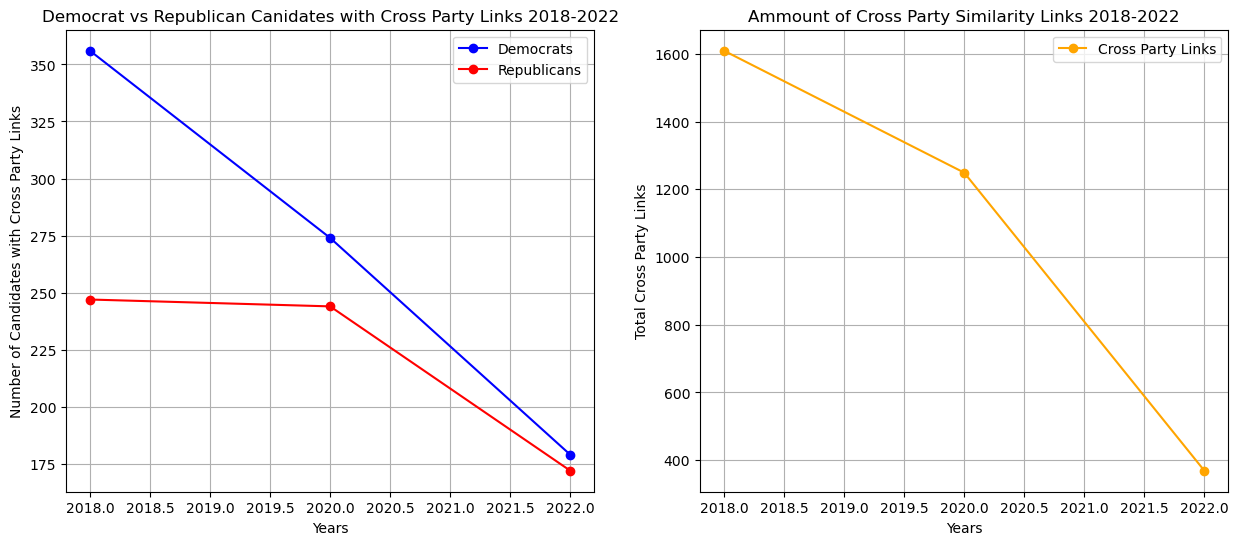

In [135]:
# Dylan Cullifer
# take the dicts that counted the number of cross party links each node has and find 
def cross_party_metrics(counts, candidates_nodes):
    # sums here to verify counts of cross party links are equal and consitent from earlier
    dem_counts = 0
    dem_sum = 0
    rep_counts = 0
    rep_sum = 0

    # Democrats
    for candidate in candidates_nodes[0]:
        if(counts[candidate] > 0):
            dem_counts += 1
            dem_sum = dem_sum + counts[candidate]
    # Republicans
    for candidate in candidates_nodes[1]:
        if(counts[candidate] > 0):
            rep_counts += 1
            rep_sum = rep_sum + counts[candidate]

    return [dem_counts, dem_sum], [rep_counts, rep_sum]

dem_2018, rep_2018 = cross_party_metrics(cross_party_counts_2018_LCC, candidate_nodes_2018_LCC)
dem_2020, rep_2020 = cross_party_metrics(cross_party_counts_2020_LCC, candidate_nodes_2020_LCC)
dem_2022, rep_2022 = cross_party_metrics(cross_party_counts_2022_LCC, candidate_nodes_2022_LCC)

print("2018 LCC:", "Dems with Cross party link =", dem_2018[0], "/ Reps with Cross party link =", rep_2018[0], "/ total links =", dem_2018[1])
print("2020 LCC:", "Dems with Cross party link =", dem_2020[0], "/ Reps with Cross party link =", rep_2020[0], "/ total links =", dem_2020[1])
print("2022 LCC:", "Dems with Cross party link =", dem_2022[0], "/ Reps with Cross party link =", rep_2022[0], "/ total links =", dem_2022[1])

# graph party paricipation in cross party links and ammount of links
plt.close("all")
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.title("Democrat vs Republican Canidates with Cross Party Links 2018-2022")
plt.plot(years, [dem_2018[0], dem_2020[0], dem_2022[0]], color="blue", label="Democrats", marker="o")
plt.plot(years, [rep_2018[0], rep_2020[0], rep_2022[0]], color="red", label="Republicans", marker="o")
plt.legend()
plt.grid(True)
plt.xlabel("Years")
plt.ylabel("Number of Candidates with Cross Party Links")

plt.subplot(1, 2, 2)
plt.title("Ammount of Cross Party Similarity Links 2018-2022")
plt.plot(years, [dem_2018[1], dem_2020[1], dem_2022[1]], color="orange", label="Cross Party Links", marker="o")
plt.legend()
plt.grid(True)
plt.xlabel("Years")
plt.ylabel("Total Cross Party Links")
plt.show()

The above shows the trends over time of the amount of total cross party edges in each network graph. We can see a sharp drop in total party links from 2018-2022 signaling that there is a significant drop in platform overlap and candidates either disagree on topics or are talking about different thing altogether. The graph on the left shows the number of candidates within each group that have at least 1 link with a member of the other group. Democrats and Republicans both see a large drops in members having common platforms with the other party showing the trend towards more polarized candidates. The large number of Democrats in 2018 having links show that they likely had more moderates since they have a much higher number of candidates sharing stances with republicans.

## References

### Dylan Cullifer:
- https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2
- https://matplotlib.org/
- https://networkx.org/documentation/stable/
- https://www.includehelp.com/python/horizontal-subplot.aspx

LLM Log:

"I have a very dense matplotlib network plot what can I do to make the plot easier to read?"
- I found a few arguments and setting for the positions that help fix the plot layout

"How to add a clean legend to a networkx plot in matplotlib?"
- the plt.legend() can sometimes be made automatically but with networks it takes a little more which I referenced in making mine

"I have a data frame with columns that vary and some that don't how can I collapse the rows with changing values into a list?"
- referenced when setting up the data so i would not lose any data but also remove the excess candidate entries since there was one entry for every policy point

"what figure size should I use to fit a matpltlib plot on a full powerpoint slide?"
- used these values to get the largest and bets looking plot for the presentation slides

"good way to increase node size in a networkx plot by its degree importance to a limit"
- referenced modified to make varying node sizes for better readability

Packages:

networkx
- Used in graph creation, allows the build and plotting of network graphs standard package used within our class.

numpy
- needed for handling embeddings and other values easier.

matplotlib
- Used to plot all my networks and metric graphs.

sklearn
- used to compute cosine similarity metrics between embeddings (vectors).

pandas
- utilized for data handling, this data set is very large and needed condensing and data frames helped with this.

sentence_transformers
- allows the import and use of sentence transformer models to calculate the semantic meaning of our candidate platforms.